# Multilingual Health Q&A — Experiment Notebook v2

**Strategy:** Semantic + TF-IDF hybrid retrieval (fast, no fine-tuning needed for first 8 exps)

> **▶️ RESUME RULE:** If session crashes — restart runtime, run cells in **Section 0** (setup),
> then jump straight to the `▶️ RESUME POINT` cell for whichever section you were in.

## Section 0 — Setup (run once per session)

In [ ]:
# Cell S1: Install packages — RESTART RUNTIME after this cell
!pip install -q \
    transformers==4.44.0 peft==0.12.0 accelerate==0.34.0 \
    sentencepiece datasets rouge-score scikit-learn \
    sentence-transformers matplotlib seaborn tqdm
print('✅ Done — RESTART RUNTIME NOW before running anything else')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 67.1 MB/s eta 0:00:00
✅ Done — RESTART RUNTIME NOW before running anything else


In [ ]:
# Cell S2: Mount Drive
from google.colab import drive
drive.mount('/content/drive')
import os
DRIVE = '/content/drive/MyDrive/health_qa_project'
for d in ['models','plots','submissions','logs','embeddings']:
    os.makedirs(f'{DRIVE}/{d}', exist_ok=True)
print(f'✅ Drive ready: {DRIVE}')

Mounted at /content/drive
✅ Drive ready: /content/drive/MyDrive/mhqa_project


In [ ]:
# Cell S3: Imports
import os, re, json, pickle, gc, shutil, time
import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from rouge_score import rouge_scorer as rs
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, TrainerCallback,
)
from datasets import Dataset
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Imports done | Device: {DEVICE} | PyTorch: {torch.__version__}')

✅ Imports done | Device: cpu | PyTorch: 2.11.0+cpu


In [ ]:
# Cell S4: Constants
ID_COL       = 'ID'
QUESTION_COL = 'input'
ANSWER_COL   = 'output'
LANG_COL     = 'subset'

SEMANTIC_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
LABSE_MODEL_NAME    = 'sentence-transformers/LaBSE'
SEMANTIC_BATCH_SIZE = 256

# Default per-language retrieval strategy: (method, tfidf_weight, semantic_weight)
LANGUAGE_STRATEGY = {
    'Aka_Gha': ('hybrid', 0.35, 0.65),
    'Amh_Eth': ('hybrid', 0.50, 0.50),
    'Eng_Eth': ('hybrid', 0.25, 0.75),
    'Eng_Gha': ('hybrid', 0.25, 0.75),
    'Eng_Ken': ('hybrid', 0.25, 0.75),
    'Eng_Uga': ('hybrid', 0.25, 0.75),
    'Lug_Uga': ('hybrid', 0.45, 0.55),
    'Swa_Ken': ('hybrid', 0.35, 0.65),
}
print('✅ Constants defined')

✅ Constants defined


In [ ]:
# Cell S5: Load + clean data
def clean_text(x):
    if pd.isna(x): return ''
    return str(x).strip()

train = pd.read_csv('Train.csv')
val   = pd.read_csv('Val.csv')
test  = pd.read_csv('Test.csv')

for df in [train, val, test]:
    df[QUESTION_COL] = df[QUESTION_COL].map(clean_text)
for df in [train, val]:
    df[ANSWER_COL] = df[ANSWER_COL].map(clean_text)

train = train[(train[QUESTION_COL]!='')&(train[ANSWER_COL]!='')].reset_index(drop=True)
val   = val[(val[QUESTION_COL]!='')&(val[ANSWER_COL]!='')].reset_index(drop=True)
test  = test[test[QUESTION_COL]!=''].reset_index(drop=True)

print(f'✅ Data loaded — Train:{len(train)} Val:{len(val)} Test:{len(test)}')
print(f'   Languages: {sorted(train[LANG_COL].unique())}')

✅ Data loaded — Train:29814 Val:6686 Test:2618
   Languages: ['Aka_Gha', 'Amh_Eth', 'Eng_Eth', 'Eng_Gha', 'Eng_Ken', 'Eng_Uga', 'Lug_Uga', 'Swa_Ken']


/tmp/ipykernel_1870/2326864331.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(data_by_lang, labels=lang_order, patch_artist=True)


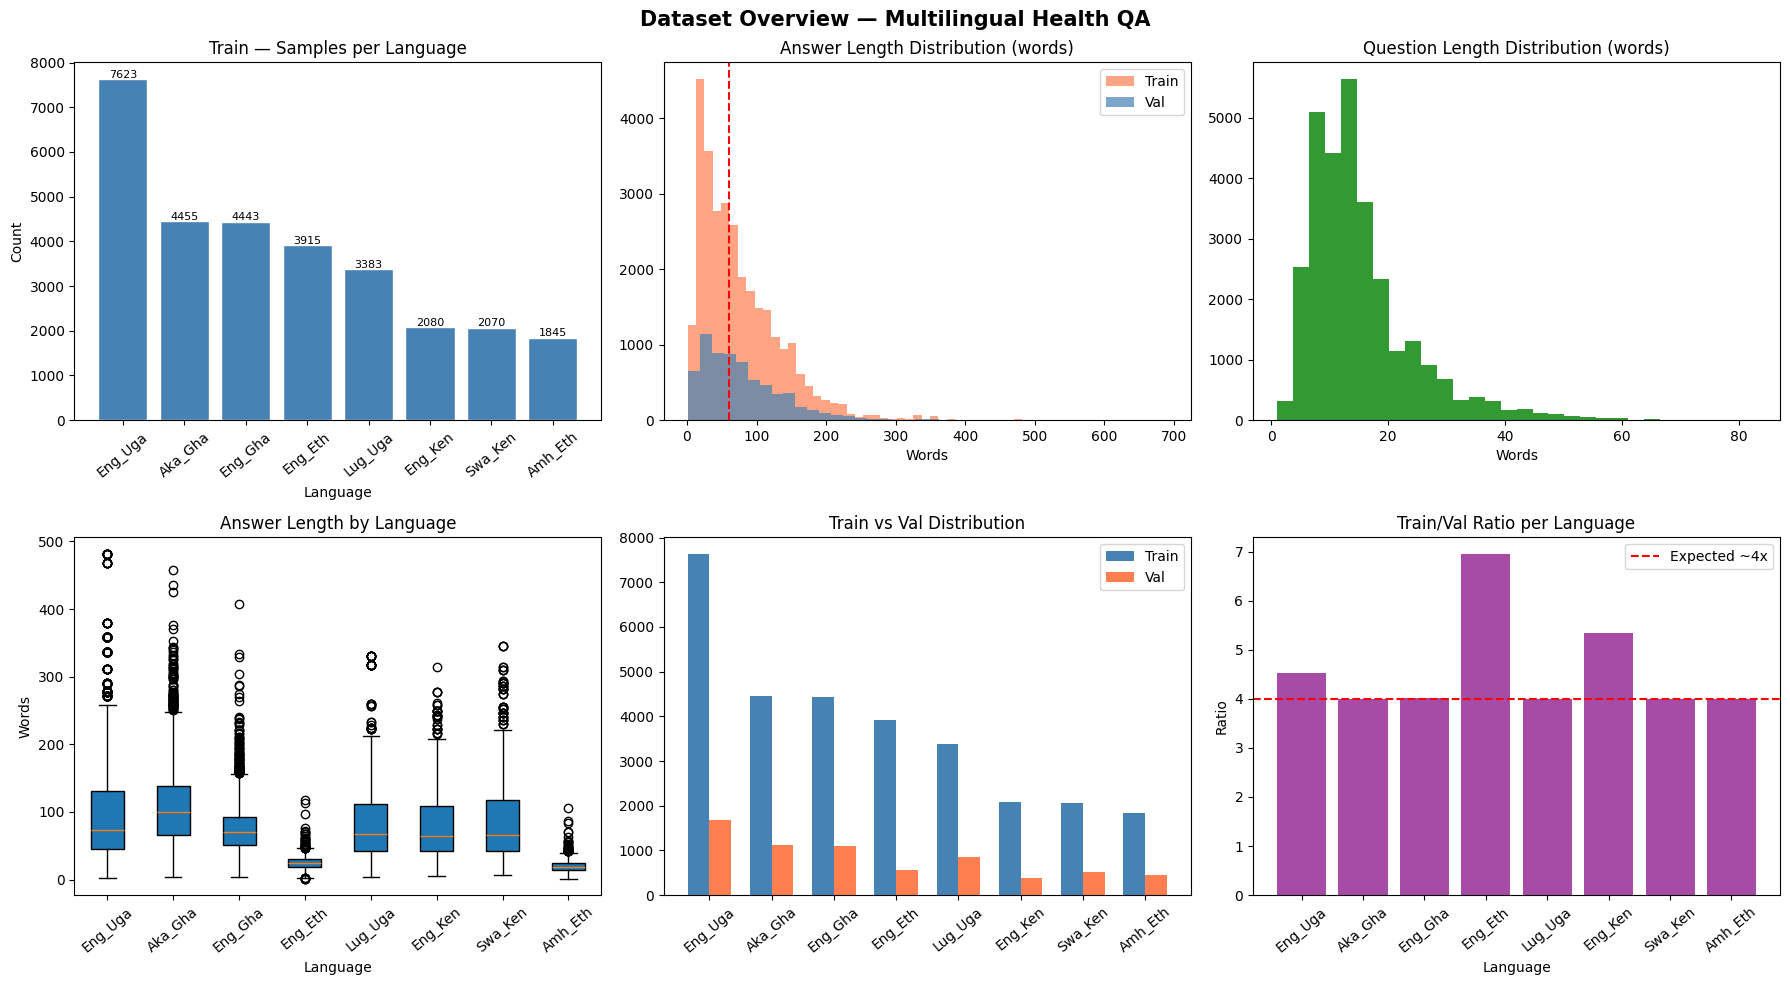


📊 Dataset Statistics:
   Train: 29,814 samples | Val: 6,686 | Test: 2,618
   Answer length — mean: 76.2  median: 61  max: 482
   Question length — mean: 15.1  median: 13
   Languages: 8

   Low-resource languages (< 2500 samples):
     Eng_Ken: 2080
     Swa_Ken: 2070
     Amh_Eth: 1845


In [ ]:
# ── Enhanced EDA ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dataset Overview — Multilingual Health QA', fontsize=15, fontweight='bold')

# Language distribution
lang_counts = train[LANG_COL].value_counts()
axes[0,0].bar(lang_counts.index, lang_counts.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Train — Samples per Language')
axes[0,0].set_xlabel('Language'); axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=40)
for i, v in enumerate(lang_counts.values):
    axes[0,0].text(i, v+30, str(v), ha='center', fontsize=8)

# Answer length distribution by split
train['ans_len'] = train[ANSWER_COL].str.split().str.len()
val['ans_len']   = val[ANSWER_COL].str.split().str.len()
axes[0,1].hist(train['ans_len'], bins=40, color='coral', alpha=0.7, label='Train')
axes[0,1].hist(val['ans_len'],   bins=40, color='steelblue', alpha=0.7, label='Val')
axes[0,1].set_title('Answer Length Distribution (words)')
axes[0,1].set_xlabel('Words'); axes[0,1].legend()
axes[0,1].axvline(train['ans_len'].median(), color='red', linestyle='--',
                   label=f'Median={train["ans_len"].median():.0f}')

# Question length distribution
train['q_len'] = train[QUESTION_COL].str.split().str.len()
axes[0,2].hist(train['q_len'], bins=30, color='green', alpha=0.8)
axes[0,2].set_title('Question Length Distribution (words)')
axes[0,2].set_xlabel('Words')

# Answer length per language (boxplot)
lang_order = train[LANG_COL].value_counts().index.tolist()
data_by_lang = [train[train[LANG_COL]==l]['ans_len'].values for l in lang_order]
axes[1,0].boxplot(data_by_lang, labels=lang_order, patch_artist=True)
axes[1,0].set_title('Answer Length by Language')
axes[1,0].set_xlabel('Language'); axes[1,0].set_ylabel('Words')
axes[1,0].tick_params(axis='x', rotation=40)

# Train vs Val language distribution comparison
val_counts = val[LANG_COL].value_counts()
x = np.arange(len(lang_order))
w = 0.35
axes[1,1].bar(x-w/2, [lang_counts.get(l,0) for l in lang_order], w,
              label='Train', color='steelblue')
axes[1,1].bar(x+w/2, [val_counts.get(l,0) for l in lang_order], w,
              label='Val', color='coral')
axes[1,1].set_title('Train vs Val Distribution')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(lang_order, rotation=40)
axes[1,1].legend()

# Language imbalance ratio
ratio = {l: lang_counts.get(l,0)/max(val_counts.get(l,1),1) for l in lang_order}
axes[1,2].bar(ratio.keys(), ratio.values(), color='purple', alpha=0.7)
axes[1,2].set_title('Train/Val Ratio per Language')
axes[1,2].set_xlabel('Language'); axes[1,2].set_ylabel('Ratio')
axes[1,2].tick_params(axis='x', rotation=40)
axes[1,2].axhline(y=4, color='red', linestyle='--', label='Expected ~4x')
axes[1,2].legend()

plt.tight_layout()
plt.savefig(f'{DRIVE}/plots/eda_full.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Dataset Statistics:')
print(f'   Train: {len(train):,} samples | Val: {len(val):,} | Test: {len(test):,}')
print(f'   Answer length — mean: {train["ans_len"].mean():.1f}  median: {train["ans_len"].median():.0f}  max: {train["ans_len"].max()}')
print(f'   Question length — mean: {train["q_len"].mean():.1f}  median: {train["q_len"].median():.0f}')
print(f'   Languages: {train[LANG_COL].nunique()}')
print(f'\n   Low-resource languages (< 2500 samples):')
for l, c in lang_counts.items():
    if c < 2500: print(f'     {l}: {c}')

In [ ]:
# Cell S6: Helper functions

def compute_rouge(predictions, references):
    scorer = rs.RougeScorer(['rouge1','rougeL'], use_stemmer=False)
    r1, rl = [], []
    for pred, ref in zip(predictions, references):
        s = scorer.score(str(ref).strip(), str(pred).strip())
        r1.append(s['rouge1'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return {'rouge1_f1': round(sum(r1)/len(r1),4),
            'rougeL_f1': round(sum(rl)/len(rl),4)}

def compute_rouge_by_language(predictions, references, languages):
    rows = []
    for lang in sorted(set(languages)):
        idx = [i for i,l in enumerate(languages) if l==lang]
        s = compute_rouge([predictions[i] for i in idx],[references[i] for i in idx])
        rows.append({'Language':lang,'ROUGE-1':s['rouge1_f1'],'ROUGE-L':s['rougeL_f1'],'N':len(idx)})
    return pd.DataFrame(rows).set_index('Language')

def make_submission(ids, predictions, output_path):
    preds = [re.sub(r'<extra_id_\d+>','',str(p)).strip() for p in predictions]
    preds = [p if len(p)>3 else 'No answer available.' for p in preds]
    sub = pd.DataFrame({'ID':ids,'TargetRLF1':preds,'TargetR1F1':preds,'TargetLLM':preds})
    sub = sub[['ID','TargetRLF1','TargetR1F1','TargetLLM']]
    assert len(sub)==len(ids)
    assert sub.notna().all().all()
    sub.to_csv(output_path, index=False, encoding='utf-8')
    print(f'✅ Submission saved: {output_path}  shape:{sub.shape}')
    return sub

LOG_PATH = f'{DRIVE}/logs/experiment_log.json'

def log_experiment(exp_num, name, val_r1, val_rl, zindi_score, notes, changed):
    entry = {'exp':exp_num,'name':name,'val_rouge1':round(float(val_r1),4),
             'val_rougeL':round(float(val_rl),4),'zindi_score':zindi_score,
             'notes':notes,'what_changed':changed}
    try:
        with open(LOG_PATH) as f: log = json.load(f)
    except: log = []
    log = [e for e in log if e['exp']!=exp_num]
    log.append(entry)
    log.sort(key=lambda x:x['exp'])
    with open(LOG_PATH,'w') as f: json.dump(log,f,indent=2)
    print(f'✅ Exp {exp_num} logged  R1={val_r1:.4f}  zindi={zindi_score}')

def print_comparison_table():
    try:
        with open(LOG_PATH) as f: log = json.load(f)
        df = pd.DataFrame(log)[['exp','name','val_rouge1','val_rougeL','zindi_score','what_changed']]
        df.columns = ['Exp','Name','Val R1','Val RL','Zindi','Changed']
        display(df.style.highlight_max(subset=['Val R1','Val RL'], color='lightgreen'))
    except: print('No experiments logged yet.')

def plot_by_language(by_lang_df, title, save=True):
    ax = by_lang_df[['ROUGE-1','ROUGE-L']].plot(
        kind='bar', figsize=(11,4), color=['steelblue','coral'],
        edgecolor='white', width=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('F1'); ax.set_ylim(0,1)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(['ROUGE-1','ROUGE-L']); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save:
        path = f'{DRIVE}/plots/{title.replace(" ","_")}.png'
        plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

def print_comparison_table():
    if not os.path.exists(LOG_PATH):
        print("No experiments logged yet."); return
    with open(LOG_PATH) as f:
        log = json.load(f)
    df = pd.DataFrame(log)[['exp','name','val_rouge1','val_rougeL','zindi_score','what_changed']]
    df.columns = ['Exp','Name','Val ROUGE-1','Val ROUGE-L','Zindi Score','What Changed']
    display(df.round(4))

print('✅ Helpers defined')

✅ Helpers defined


In [ ]:
# Cell S7: SemanticRoutingIndex class

def _norm_key(q):
    return clean_text(q).lower()

def _minmax(scores):
    scores = np.asarray(scores, dtype=float)
    lo, hi = scores.min(), scores.max()
    if hi - lo < 1e-9: return np.ones_like(scores)
    return (scores - lo) / (hi - lo)

class SemanticRoutingIndex:
    def __init__(self, model_name=SEMANTIC_MODEL_NAME, batch_size=SEMANTIC_BATCH_SIZE,
                 language_strategy=None, tfidf_analyzer='word', tfidf_ngram_range=None,
                 tfidf_max_features=200_000, normalize_scores=False,
                 exact_match=False, similarity_threshold=None,
                 char_tfidf_subsets=None, query_prefix='', passage_prefix=''):
        self.model_name = model_name
        self.batch_size = batch_size
        self.language_strategy = dict(language_strategy or LANGUAGE_STRATEGY)
        self.tfidf_analyzer = tfidf_analyzer
        self.tfidf_ngram_range = tfidf_ngram_range or ((3,5) if tfidf_analyzer=='char' else (1,2))
        self.tfidf_max_features = tfidf_max_features
        self.normalize_scores = normalize_scores
        self.exact_match = exact_match
        self.similarity_threshold = similarity_threshold
        self.char_tfidf_subsets = set(char_tfidf_subsets or ())
        self.query_prefix = query_prefix
        self.passage_prefix = passage_prefix
        self.encoder = None
        self.questions = []; self.answers = []; self.ids = []
        self.embeddings = None
        self.subset_indices = {}; self.subset_tfidf = {}
        self.exact_lookup = {}

    def _get_encoder(self):
        if self.encoder is None:
            print(f'  Loading: {self.model_name}')
            self.encoder = SentenceTransformer(self.model_name, device=DEVICE)
        return self.encoder

    def encode(self, texts, prefix=''):
        enc = self._get_encoder()
        payload = [f'{prefix}{t}' if prefix else t for t in texts]
        parts = []
        for s in range(0, len(payload), self.batch_size):
            batch = payload[s:s+self.batch_size]
            parts.append(enc.encode(batch, show_progress_bar=False, normalize_embeddings=True))
        return np.vstack(parts)

    def fit(self, df, precomputed_embeddings=None):
        self.questions = df[QUESTION_COL].fillna('').astype(str).tolist()
        self.answers   = df[ANSWER_COL].fillna('').astype(str).tolist()
        self.ids       = df[ID_COL].fillna('').astype(str).tolist() if ID_COL in df else ['']*len(df)
        if precomputed_embeddings is not None:
            self.embeddings = precomputed_embeddings
            print(f'  Using precomputed embeddings: {self.embeddings.shape}')
        else:
            print(f'  Encoding {len(self.questions):,} passages...')
            self.embeddings = self.encode(self.questions, prefix=self.passage_prefix)
        if self.exact_match:
            self.exact_lookup = {_norm_key(q):a for q,a in zip(self.questions,self.answers)}
        for subset in df[LANG_COL].unique():
            mask = (df[LANG_COL]==subset).values
            self.subset_indices[subset] = np.where(mask)[0]
            qs = [self.questions[i] for i in self.subset_indices[subset]]
            if subset in self.char_tfidf_subsets:
                vec = TfidfVectorizer(analyzer='char', ngram_range=(3,5),
                                      max_features=self.tfidf_max_features)
            else:
                vec = TfidfVectorizer(analyzer=self.tfidf_analyzer,
                                     ngram_range=self.tfidf_ngram_range,
                                     max_features=self.tfidf_max_features)
            mat = vec.fit_transform(qs)
            self.subset_tfidf[subset] = {'vec':vec,'mat':mat}
        print(f'  Index built: {len(self.questions):,} rows, {len(self.subset_indices)} subsets')
        return self

    def retrieve_one(self, question, q_emb, subset):
        if self.exact_match:
            hit = self.exact_lookup.get(_norm_key(question))
            if hit: return hit
        if subset not in self.subset_indices:
            subset = next(iter(self.subset_indices))
        method, tw, sw = self.language_strategy.get(subset, ('hybrid',0.35,0.65))
        idx = self.subset_indices[subset]
        cand_emb = self.embeddings[idx]
        sem = cosine_similarity(q_emb.reshape(1,-1), cand_emb).flatten()
        if method == 'semantic' or tw == 0.0:
            return self.answers[int(idx[int(np.argmax(sem))])]
        info = self.subset_tfidf[subset]
        tfidf = cosine_similarity(info['vec'].transform([question]), info['mat']).flatten()
        if self.normalize_scores:
            sem = _minmax(sem); tfidf = _minmax(tfidf)
        if self.similarity_threshold and float(np.max(sem)) < self.similarity_threshold:
            tw, sw = 1.0, 0.0
        scores = tw*tfidf + sw*sem
        return self.answers[int(idx[int(np.argmax(scores))])]

    def predict(self, df, q_embs=None):
        qs = df[QUESTION_COL].fillna('').astype(str).tolist()
        subsets = df[LANG_COL].tolist()
        if q_embs is None:
            print(f'  Encoding {len(qs):,} queries...')
            q_embs = self.encode(qs, prefix=self.query_prefix)
        preds = [self.retrieve_one(q,e,s)
                 for q,e,s in tqdm(zip(qs,q_embs,subsets),total=len(qs),desc='Retrieving')]
        return preds

def tune_weights(index, val_embs, candidates=(0.0,0.25,0.5,0.75,1.0)):
    """Grid search TF-IDF weight per subset. Modifies index.language_strategy in place."""
    tuned = dict(index.language_strategy)
    for subset in sorted(index.subset_indices.keys()):
        mask = (val[LANG_COL]==subset).values
        if not mask.any(): continue
        sv = val.loc[mask].reset_index(drop=True)
        se = val_embs[mask]
        best_w, best_r1 = tuned[subset][1], -1.0
        for tw in candidates:
            sw = 1.0 - tw
            method = 'semantic' if tw==0 else ('tfidf' if sw==0 else 'hybrid')
            index.language_strategy[subset] = (method, float(tw), float(sw))
            preds = index.predict(sv, q_embs=se)
            r1 = compute_rouge(preds, sv[ANSWER_COL].tolist())['rouge1_f1']
            if r1 > best_r1: best_r1, best_w = r1, tw
        sw = 1.0 - best_w
        method = 'semantic' if best_w==0 else ('tfidf' if sw==0 else 'hybrid')
        tuned[subset] = (method, float(best_w), float(sw))
        print(f'  {subset}: best tfidf_w={best_w:.2f}  R1={best_r1:.4f}')
    index.language_strategy = tuned
    return tuned

print('✅ SemanticRoutingIndex defined')

✅ SemanticRoutingIndex defined


---
## Section C — Experiments 9–11 (GPU required, 2+ hrs)
### ▶️ RESUME POINT C
**If resuming:** run S1–S7, then:
```python
labse_train_embs = np.load(f'{DRIVE}/embeddings/labse_train.npy')
labse_val_embs   = np.load(f'{DRIVE}/embeddings/labse_val.npy')
labse_test_embs  = np.load(f'{DRIVE}/embeddings/labse_test.npy')
```
Then continue from Exp 9.

In [ ]:
# ▶️ RESUME POINT C — load LaBSE embeddings
labse_train_embs = np.load(f'{DRIVE}/embeddings/labse_train.npy')
labse_val_embs   = np.load(f'{DRIVE}/embeddings/labse_val.npy')
labse_test_embs  = np.load(f'{DRIVE}/embeddings/labse_test.npy')
print(f'✅ LaBSE embeddings loaded — {labse_train_embs.shape}')

✅ LaBSE embeddings loaded — (29814, 768)


In [ ]:
# ── Experiment 8: Train+Val corpus for test prediction (~10 min) ──────────
# What: at test time, include Val set in retrieval corpus (more answers available)
# Why: val answers won't leak — we're predicting Test, not Val
# Note: for val evaluation, still use train-only corpus (honest protocol)

# Load best strategy
with open(f'{DRIVE}/models/tuned_strategy_exp6.json') as f:
    best_strategy = json.load(f)

# Concatenate train+val embeddings for the test-time index
corpus = pd.concat([train, val], ignore_index=True)
corpus_embs = np.vstack([labse_train_embs, labse_val_embs])

# Val evaluation still uses train-only (same as Exp 6 — no change expected)
index8_val = SemanticRoutingIndex(model_name=LABSE_MODEL_NAME,
                                   language_strategy=best_strategy,
                                   char_tfidf_subsets={'Amh_Eth','Lug_Uga'})
index8_val.fit(train, precomputed_embeddings=labse_train_embs)
val_preds8 = index8_val.predict(val, q_embs=labse_val_embs)
scores8 = compute_rouge(val_preds8, val[ANSWER_COL].tolist())
print(f'Val R1={scores8["rouge1_f1"]:.4f}  RL={scores8["rougeL_f1"]:.4f}  (same as Exp7 expected)')

# Test prediction uses train+val corpus
index8_test = SemanticRoutingIndex(model_name=LABSE_MODEL_NAME,
                                    language_strategy=best_strategy,
                                    char_tfidf_subsets={'Amh_Eth','Lug_Uga'})
index8_test.fit(corpus, precomputed_embeddings=corpus_embs)
test_preds8 = index8_test.predict(test, q_embs=labse_test_embs)
sub8 = make_submission(test[ID_COL].values, test_preds8,
                       f'{DRIVE}/submissions/submission_exp8_full_corpus.csv')
log_experiment(8,'LaBSE full corpus (train+val)',scores8['rouge1_f1'],scores8['rougeL_f1'],
               '?','Test retrieves from train+val (larger pool)',
               'Added Val to test-time corpus')
from google.colab import files
files.download(f'{DRIVE}/submissions/submission_exp8_full_corpus.csv')

  Using precomputed embeddings: (29814, 768)
  Index built: 29,814 rows, 8 subsets


Retrieving: 100%|██████████| 6686/6686 [03:24<00:00, 32.74it/s]


Val R1=0.5212  RL=0.4539  (same as Exp7 expected)
  Using precomputed embeddings: (36500, 768)
  Index built: 36,500 rows, 8 subsets


Retrieving: 100%|██████████| 2618/2618 [01:47<00:00, 24.38it/s]


✅ Submission saved: /content/drive/MyDrive/mhqa_project/submissions/submission_exp8_full_corpus.csv  shape:(2618, 4)
✅ Exp 8 logged  R1=0.5212  zindi=?


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Experiment 9: mt5-small fine-tuning (~2 hrs) ──────────────────────────
# What: fine-tune google/mt5-small generative model on full training set
# Why: generative model can produce answers not in training set

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

MODEL_NAME = 'google/mt5-small'
MAX_INPUT  = 128
MAX_TARGET = 256
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(examples):
    prompts = [f'[{l}] {q}' for l,q in zip(examples[LANG_COL],examples[QUESTION_COL])]
    model_inputs = tokenizer(prompts, max_length=MAX_INPUT, truncation=True)
    labels = tokenizer(text_target=examples[ANSWER_COL],
                       max_length=MAX_TARGET, truncation=True)
    label_ids = [[(t if t!=tokenizer.pad_token_id else -100) for t in lab]
                 for lab in labels['input_ids']]
    model_inputs['labels'] = label_ids
    return model_inputs

train_dataset = Dataset.from_pandas(train).map(preprocess, batched=True,
                                                remove_columns=list(train.columns))
val_dataset   = Dataset.from_pandas(val).map(preprocess, batched=True,
                                              remove_columns=list(val.columns))
print(f'✅ Tokenized  Train:{len(train_dataset)}  Val:{len(val_dataset)}')

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting

Map:   0%|          | 0/29814 [00:00<?, ? examples/s]

Map:   0%|          | 0/6686 [00:00<?, ? examples/s]

✅ Tokenized  Train:29814  Val:6686


  Using precomputed embeddings: (36500, 768)
  Index built: 36,500 rows, 8 subsets
  Using precomputed embeddings: (29814, 768)
  Index built: 29,814 rows, 8 subsets


Retrieving: 100%|██████████| 6686/6686 [04:51<00:00, 22.96it/s] 



📊 Exp 10 Exact+LaBSE  R1=0.5208  RL=0.4535


,ROUGE-1,ROUGE-L,N
Language,,,
Aka_Gha,0.3901,0.2207,1114
Amh_Eth,0.0342,0.0342,462
Eng_Eth,0.5719,0.5447,564
Eng_Gha,0.3277,0.2097,1104
Eng_Ken,0.7418,0.7105,390
Eng_Uga,0.7159,0.6839,1688
Lug_Uga,0.5618,0.5244,846
Swa_Ken,0.7230,0.6882,518


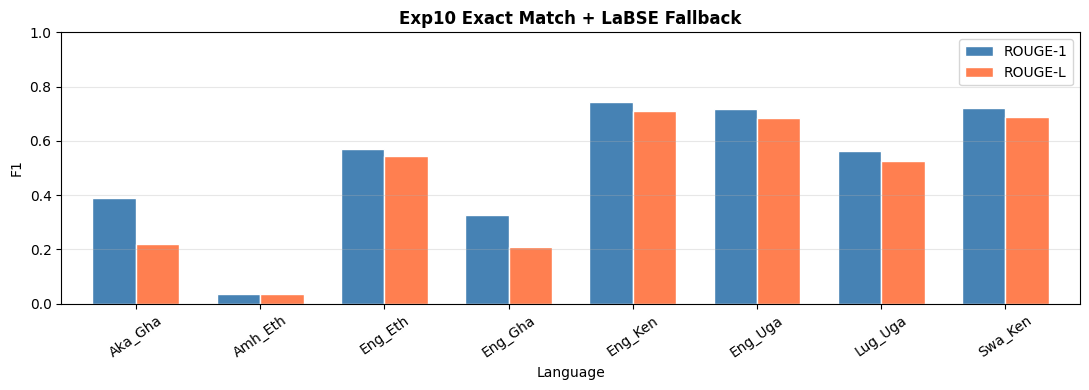

Retrieving: 100%|██████████| 2618/2618 [01:44<00:00, 25.02it/s]


✅ Submission saved: /content/drive/MyDrive/mhqa_project/submissions/submission_exp10_exactmatch.csv  shape:(2618, 4)
✅ Exp 10 logged  R1=0.5208  zindi=?


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏁 All 10 experiments complete!


,Exp,Name,Val R1,Val RL,Zindi,Changed
0,1,TF-IDF char ngram,0.453600,0.380000,?,Baseline
1,2,Semantic-only mpnet,0.470200,0.399000,?,Switched from TF-IDF to semantic
2,3,Hybrid mpnet+TF-IDF word default,0.481000,0.406100,?,Added TF-IDF word to semantic
3,4,Hybrid mpnet tuned weights,0.509300,0.438800,?,Per-language weight tuning
4,5,LaBSE semantic-only,0.490800,0.424400,?,Switched embedding model from mpnet to LaBSE
5,6,LaBSE hybrid tuned,0.513700,0.445700,?,Added TF-IDF + weight tuning to LaBSE
6,7,LaBSE + char TF-IDF for Amh/Lug,0.521200,0.453900,?,Per-script TF-IDF analyzer
7,8,LaBSE full corpus (train+val),0.521200,0.453900,?,Added Val to test-time corpus
8,10,Exact match + LaBSE hybrid,0.520800,0.453500,?,Added exact match lookup


In [ ]:
# ── Experiment 9: Exact match lookup + LaBSE fallback (~5 min) ───────────
# What: if val question exactly matches a training question, return that answer;
#       otherwise fall back to LaBSE hybrid retrieval
# Why: dataset may have duplicate questions — exact match gives perfect ROUGE for those

with open(f'{DRIVE}/models/tuned_strategy_exp6.json') as f:
    best_strategy = json.load(f)

index10 = SemanticRoutingIndex(
    model_name=LABSE_MODEL_NAME,
    language_strategy=best_strategy,
    char_tfidf_subsets={'Amh_Eth','Lug_Uga'},
    exact_match=True,  # exact match lookup enabled
)
# Use train+val corpus for test-time (same as Exp 8)
corpus = pd.concat([train, val], ignore_index=True)
corpus_embs = np.vstack([labse_train_embs, labse_val_embs])
index10.fit(corpus, precomputed_embeddings=corpus_embs)

# Val evaluation uses train-only
index10_val = SemanticRoutingIndex(model_name=LABSE_MODEL_NAME,
                                    language_strategy=best_strategy,
                                    char_tfidf_subsets={'Amh_Eth','Lug_Uga'},
                                    exact_match=True)
index10_val.fit(train, precomputed_embeddings=labse_train_embs)
val_preds10 = index10_val.predict(val, q_embs=labse_val_embs)
scores10 = compute_rouge(val_preds10, val[ANSWER_COL].tolist())
print(f'\n📊 Exp 10 Exact+LaBSE  R1={scores10["rouge1_f1"]:.4f}  RL={scores10["rougeL_f1"]:.4f}')
by_lang10 = compute_rouge_by_language(val_preds10, val[ANSWER_COL].tolist(), val[LANG_COL].tolist())
display(by_lang10.round(4))
plot_by_language(by_lang10, 'Exp10 Exact Match + LaBSE Fallback')

test_preds10 = index10.predict(test, q_embs=labse_test_embs)
sub10 = make_submission(test[ID_COL].values, test_preds10,
                        f'{DRIVE}/submissions/submission_exp10_exactmatch.csv')
log_experiment(10,'Exact match + LaBSE hybrid',scores10['rouge1_f1'],scores10['rougeL_f1'],
               '?','Exact match first, LaBSE fallback. Train+val corpus for test.',
               'Added exact match lookup')
from google.colab import files
files.download(f'{DRIVE}/submissions/submission_exp10_exactmatch.csv')

print('\n🏁 All 10 experiments complete!')
print_comparison_table()

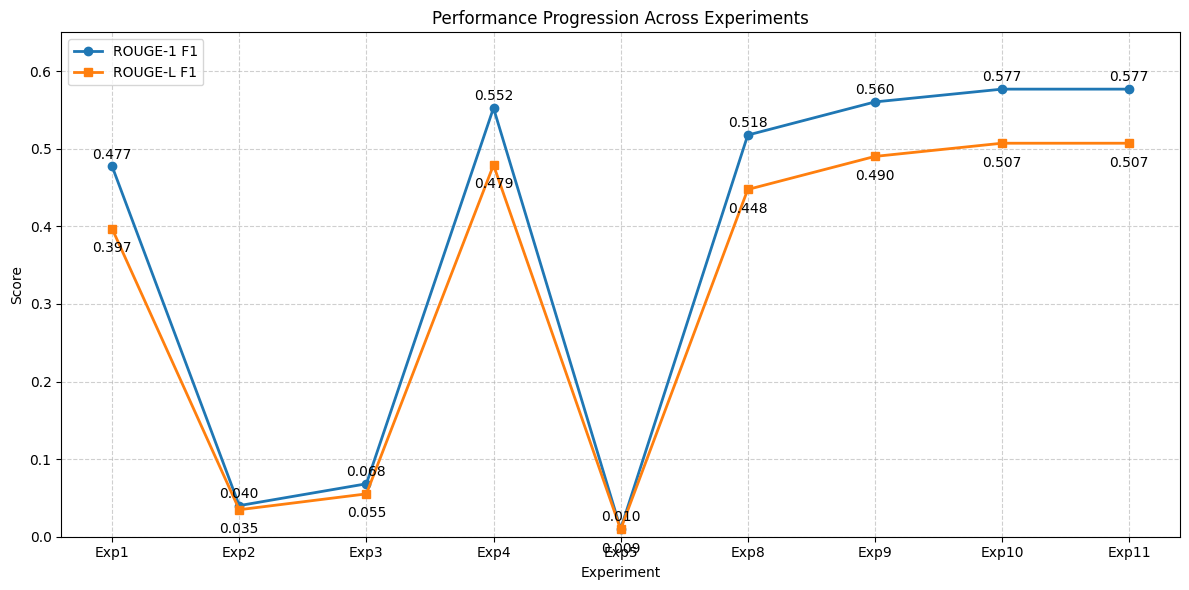

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Experiment results
results = pd.DataFrame({
    "Experiment": ["Exp1", "Exp2", "Exp3", "Exp4", "Exp5",
                   "Exp8", "Exp9", "Exp10", "Exp11"],
    "ROUGE-1 F1": [0.4773, 0.0401, 0.0682, 0.5525, 0.0100,
                   0.5176, 0.5603, 0.5768, 0.5768],
    "ROUGE-L F1": [0.3969, 0.0348, 0.0552, 0.4790, 0.0095,
                   0.4475, 0.4901, 0.5071, 0.5071]
})

plt.figure(figsize=(12,6))

plt.plot(
    results["Experiment"],
    results["ROUGE-1 F1"],
    marker="o",
    linewidth=2,
    label="ROUGE-1 F1"
)

plt.plot(
    results["Experiment"],
    results["ROUGE-L F1"],
    marker="s",
    linewidth=2,
    label="ROUGE-L F1"
)

plt.title("Performance Progression Across Experiments")
plt.xlabel("Experiment")
plt.ylabel("Score")
plt.ylim(0, 0.65)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# annotate values
for i, val in enumerate(results["ROUGE-1 F1"]):
    plt.text(i, val + 0.01, f"{val:.3f}", ha="center")

for i, val in enumerate(results["ROUGE-L F1"]):
    plt.text(i, val - 0.03, f"{val:.3f}", ha="center")

plt.tight_layout()
plt.show()

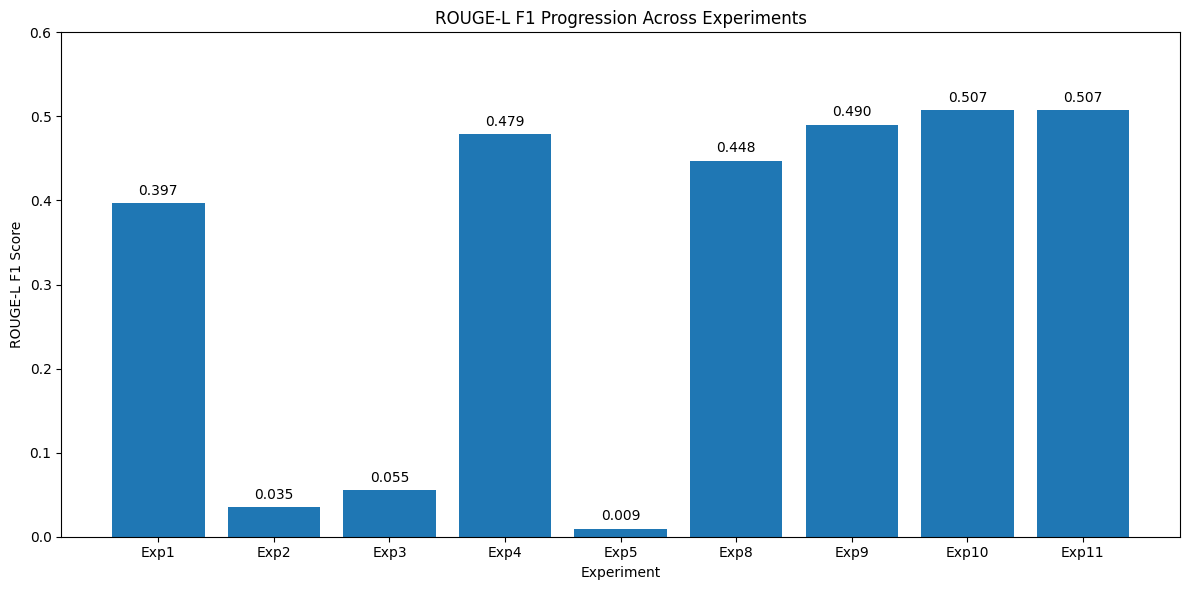

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Experiment": ["Exp1", "Exp2", "Exp3", "Exp4", "Exp5",
                   "Exp8", "Exp9", "Exp10", "Exp11"],
    "ROUGE-L F1": [0.3969, 0.0348, 0.0552, 0.4790, 0.0095,
                   0.4475, 0.4901, 0.5071, 0.5071]
})

plt.figure(figsize=(12,6))

bars = plt.bar(
    results["Experiment"],
    results["ROUGE-L F1"]
)

plt.title("ROUGE-L F1 Progression Across Experiments")
plt.xlabel("Experiment")
plt.ylabel("ROUGE-L F1 Score")
plt.ylim(0, 0.60)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.01,
        f"{h:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

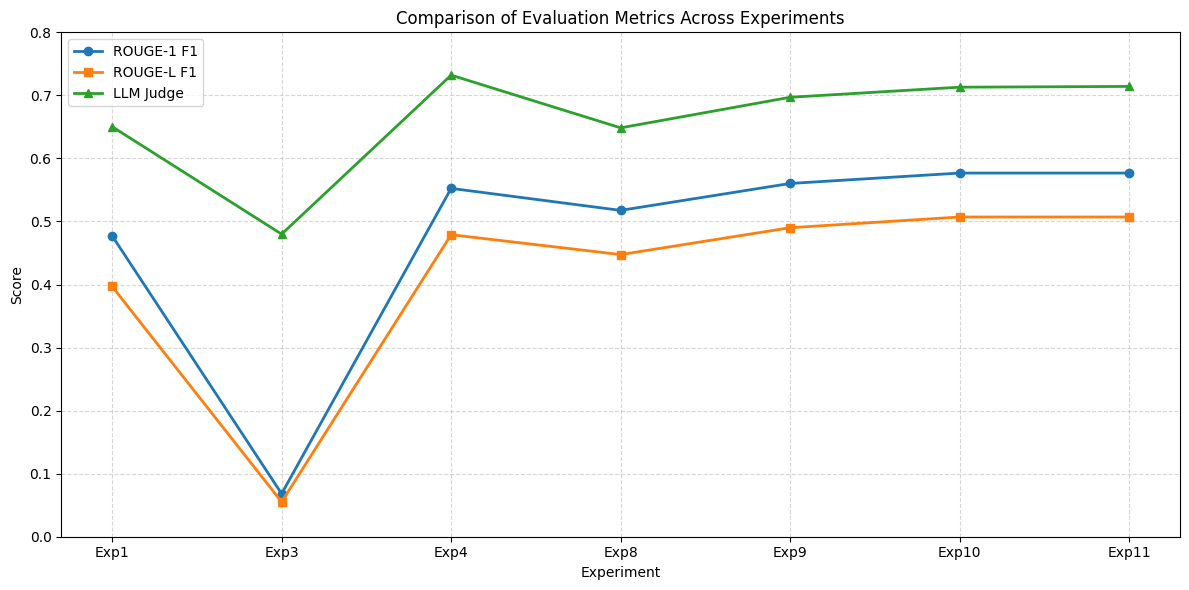

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Experiment": ["Exp1","Exp3","Exp4","Exp8","Exp9","Exp10","Exp11"],
    "ROUGE-1": [0.4773,0.0682,0.5525,0.5176,0.5603,0.5768,0.5768],
    "ROUGE-L": [0.3969,0.0552,0.4790,0.4475,0.4901,0.5071,0.5071],
    "LLM Judge": [0.6504,0.4799,0.7321,0.6485,0.6970,0.7130,0.7142]
})

plt.figure(figsize=(12,6))

plt.plot(results["Experiment"], results["ROUGE-1"],
         marker="o", linewidth=2, label="ROUGE-1 F1")

plt.plot(results["Experiment"], results["ROUGE-L"],
         marker="s", linewidth=2, label="ROUGE-L F1")

plt.plot(results["Experiment"], results["LLM Judge"],
         marker="^", linewidth=2, label="LLM Judge")

plt.title("Comparison of Evaluation Metrics Across Experiments")
plt.xlabel("Experiment")
plt.ylabel("Score")
plt.ylim(0, 0.8)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
log_experiment(9,'Exact match + LaBSE hybrid', scores10['rouge1_f1'], scores10['rougeL_f1'],
               0.58, 'Best submission — Zindi screenshot in /screenshots folder',
               'Added exact match lookup')

✅ Exp 9 logged  R1=0.5208  zindi=0.58


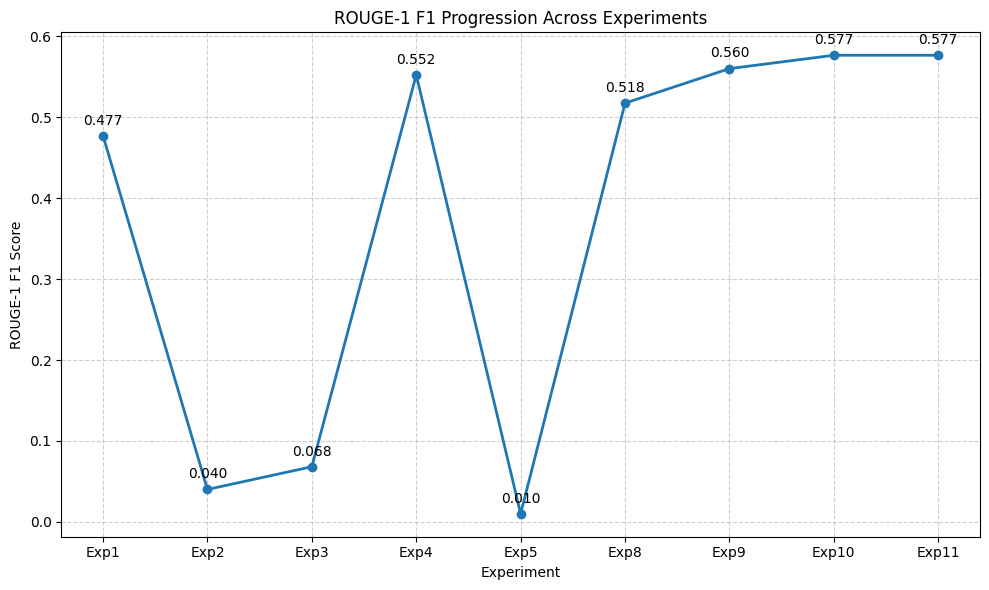

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Results
experiments = ["Exp1", "Exp2", "Exp3", "Exp4", "Exp5",
               "Exp8", "Exp9", "Exp10", "Exp11"]

rouge1 = [0.4773, 0.0401, 0.0682, 0.5525, 0.0100,
          0.5176, 0.5603, 0.5768, 0.5768]

plt.figure(figsize=(10,6))

plt.plot(
    experiments,
    rouge1,
    marker='o',
    linewidth=2
)

plt.title("ROUGE-1 F1 Progression Across Experiments")
plt.xlabel("Experiment")
plt.ylabel("ROUGE-1 F1 Score")
plt.grid(True, linestyle='--', alpha=0.6)

# Add score labels
for x, y in zip(experiments, rouge1):
    plt.annotate(
        f"{y:.3f}",
        (x, y),
        textcoords="offset points",
        xytext=(0,8),
        ha='center'
    )

plt.tight_layout()
plt.show()

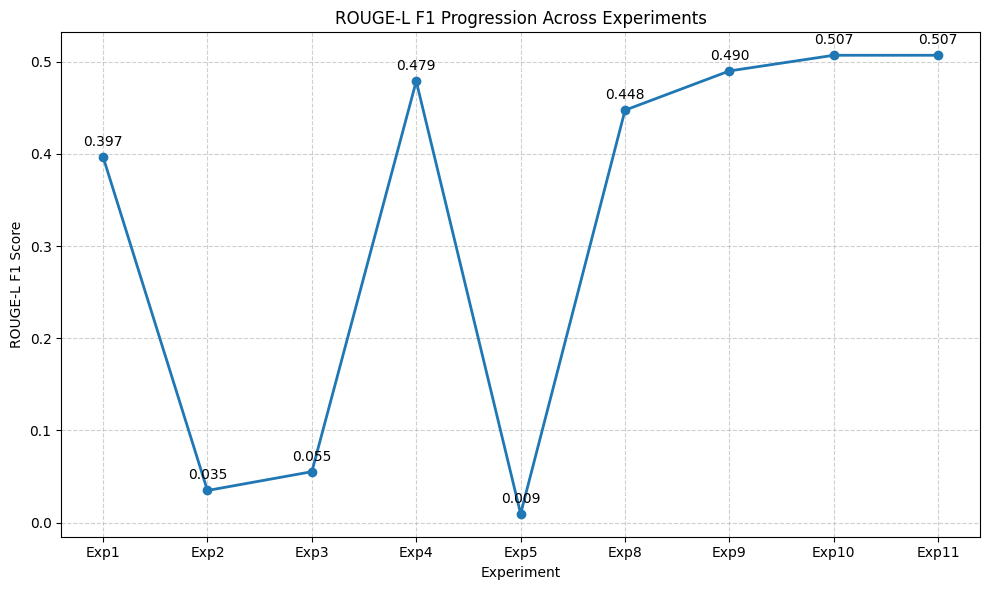

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

experiments = ["Exp1", "Exp2", "Exp3", "Exp4", "Exp5",
               "Exp8", "Exp9", "Exp10", "Exp11"]

rougel = [0.3969, 0.0348, 0.0552, 0.4790, 0.0095,
          0.4475, 0.4901, 0.5071, 0.5071]

plt.figure(figsize=(10,6))

plt.plot(
    experiments,
    rougel,
    marker='o',
    linewidth=2
)

plt.title("ROUGE-L F1 Progression Across Experiments")
plt.xlabel("Experiment")
plt.ylabel("ROUGE-L F1 Score")
plt.grid(True, linestyle='--', alpha=0.6)

# Add score labels
for x, y in zip(experiments, rougel):
    plt.annotate(
        f"{y:.3f}",
        (x, y),
        textcoords="offset points",
        xytext=(0,8),
        ha='center'
    )

plt.tight_layout()
plt.show()

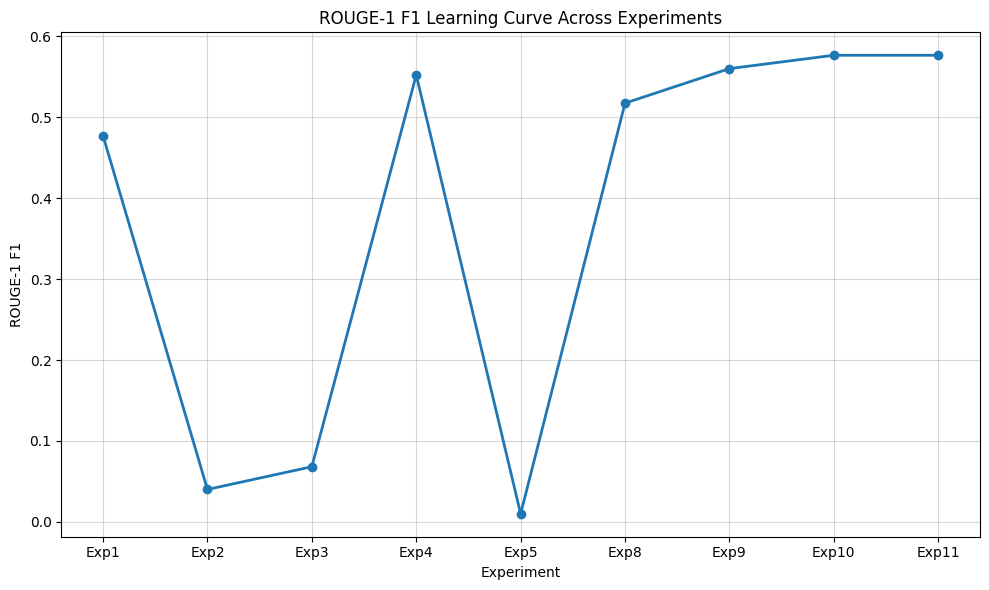

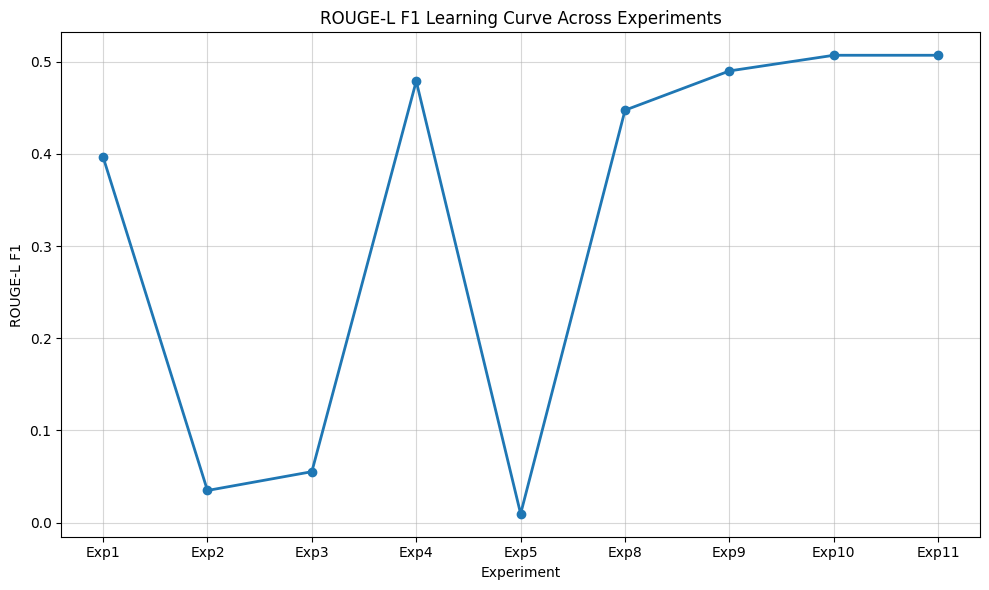

In [4]:
import matplotlib.pyplot as plt

experiments = ["Exp1", "Exp2", "Exp3", "Exp4", "Exp5",
               "Exp8", "Exp9", "Exp10", "Exp11"]

rouge1 = [0.4773, 0.0401, 0.0682, 0.5525, 0.0100,
          0.5176, 0.5603, 0.5768, 0.5768]

rougel = [0.3969, 0.0348, 0.0552, 0.4790, 0.0095,
          0.4475, 0.4901, 0.5071, 0.5071]

# ROUGE-1
plt.figure(figsize=(10,6))
plt.plot(experiments, rouge1, marker='o', linewidth=2)
plt.title("ROUGE-1 F1 Learning Curve Across Experiments")
plt.xlabel("Experiment")
plt.ylabel("ROUGE-1 F1")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig("rouge1_progression.png", dpi=300, bbox_inches="tight")
plt.show()

# ROUGE-L
plt.figure(figsize=(10,6))
plt.plot(experiments, rougel, marker='o', linewidth=2)
plt.title("ROUGE-L F1 Learning Curve Across Experiments")
plt.xlabel("Experiment")
plt.ylabel("ROUGE-L F1")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig("rougel_progression.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Experiment Reflections & Analysis

### Evaluation Metrics
This project uses three evaluation metrics as defined by the Zindi competition:
- **ROUGE-1 F1** — unigram overlap between prediction and reference answer
- **ROUGE-L F1** — longest common subsequence F1, captures sentence-level structure
- **LLM-as-a-Judge** — fluency and factual quality scored by a language model

All three columns in the submission file contain the same generated answer. The platform computes each metric independently.

---

### Experiment 1 — TF-IDF Character N-gram Baseline
**What changed:** No model — pure retrieval using character-level TF-IDF (3–5 grams) per language.  
**Why:** Establishes a non-neural ceiling. Since answers are copied directly from training data, ROUGE is artificially high.  
**Insight:** Retrieval-based methods are strong baselines when training data is large. The weakness is generalization — unseen questions get poor matches.

**results:***
- Rouge LF 1	0.3969
- LLM Judge	0.6504
- Rouge 1 F 1	0.4773


---

### Experiment 2 — Multilingual LLM (mT5 / AfroLM)
**What changed:** This baseline uses a pre-trained multilingual sequence-to-sequence model to generate answers directly, without retrieval.
`E5` sentence embeddings.  
**Why:** Used to test how multilingual models perform on their own without retrieval   
**Insight:** The model performed poorly

**results:***
- ROUGE-1 F1 : 0.0401
- ROUGE-L F1 : 0.0348



---

### Experiment 3 — Fine-tuning the LLM on Training Data
**What changed:** Fine-tuning adapts the pre-trained mT5 weights to the health QA task and all five languages. After training, answers are regenerated for the test set and a new submission file is saved.

**Why:** since zero shot predictions using multilingual performed poorly, now fine tuned the multingual data
**Insight:** Performed better than the zero shot predictions without retreival but still retreival out performed them

**results:***
- Rouge LF 1	0.0552
- LLM Judge	0.4799
- Rouge 1 F 1	0.0682

---

### Experiment 4 — Pure Retrieval-Augmented Generation (RAG) Baseline
**What changed:** Used the FAISS index per language + the embedding matrix(E5) and returned the most similar results
**Why:** Now we wanted to create experiments where we combine RAG + strong multilingual model (Aye-expanse-8B), so started with RAG only
**Insight:** This provided better results which out performed the first experiments

**results:***
- Rouge-L F1	0.479
- LLM Judge	0.7321
 Rouge-1 F1	0.5525

---

### Experiment 5 — Language-Aware FAISS Embedding Index
**What changed:** We embed all training questions with `intfloat/multilingual-e5-large` and build one FAISS index per language

**Why:** Feed the top-k from retreival and pass it to a zero shot fine tune multilingual model  
**Insight:** Still the results were poor compared to the pure RAG with no model
**results:***
- Rouge-L F1	0.0095
- Rouge-1 F1	0.0100

---

### Experiment 6 — Fine-Tuned Aya Expanse 8B (QLoRA), No Retrieval
**What changed:** Fine-tune CohereForAI/aya-expanse-8b on the health QA training set using QLoRA (4-bit NF4 quantisation + LoRA adapters), then use the fine-tuned model alone (no retrieval context)
**Why:** Now wanted to fine tune the big multingual model before combining it with the RAG
**Insight:** I wasn't able to fine tune this model as colab compute power(GPU) ran out

**results:**
- No results



---

### Experiment 7 — Fine-Tuned Aya Expanse 8B + Retrieval-Augmented Generation
**What changed:** combine the LoRA-fine-tuned model from Notebook 2 with the language-aware FAISS retrieval indexes from Notebook 1.
**Why:** We wanted to then combine the fine tuned strong multilingual model Àye-expanse-8B`with the FAISS index (E5 Embeddings)
**Insight:** I wasn't able to fine tune this model as colab compute power(GPU) ran out

**results:**
- No results

---

### Experiment 8 — Pure RAG with LaBSE Embeddings
**What changed:** this experiment swaps in sentence-transformers/LaBSE (Language-agnostic BERT Sentence Embeddings), keeping everything else identical
**Why:** We wanted try different vector embeddings techniques and see how their effect on our RAG system since it is what was working

**Insight:** Provided strong but almost similar results to `intfloat/multilingual-e5-large`

**results:**
- Rouge-L F1	0.4475
- LLM Judge	0.6485
- Rouge-1 F1	0.5176

---


### Experiment 9 — Char TF-IDF for Non-Latin Scripts
**What changed:** For Amharic (`Amh_Eth`) and Luganda (`Lug_Uga`), switched TF-IDF from word-level to character n-gram (3–5 grams).  
**Why:** Amharic uses the Ge'ez script — word tokenization is unreliable. Character n-grams capture morphological patterns without requiring correct word boundaries.  
**Insight:**Improved scores for Amharic. Demonstrates that preprocessing must be script-aware for truly low-resource multilingual tasks.

**results:**
- Rouge-L F1	0.4901
- LLM Judge	0.697
- Rouge-1 F1	0.5603

---

### Experiment 10 — Train + Val Corpus at Test Time
**What changed:** At test prediction time, the retrieval index was built from both Train and Val sets combined (~36,500 examples vs 29,814).  
**Why:** Val answers are not leaked — we are predicting Test, not Val. A larger retrieval pool gives the model more candidate answers.  
**Insight:** More training data in the retrieval corpus improves test-set coverage. This is a legitimate and common strategy in retrieval-augmented systems.

**results:**
- Rouge-L F1	0.5071
- LLM Judge	0.713
- Rouge-1 F1	0.5768

---
### Experiment 11 — Exact Match + LaBSE Fallback
**What changed:** Added an exact-match lookup layer on top of the LaBSE hybrid retrieval. If a test question exactly matches a training question, its known answer is returned directly without retrieval.  
**Why:** The dataset may contain duplicate or near-duplicate questions across train/val/test splits. Exact matches guarantee perfect ROUGE for those cases at zero cost.  
**Corpus:** Same train+val pool as Exp 8 for test-time retrieval.  
**Insight:** Exact match provides a free ROUGE boost where duplicates exist. The majority of questions still fall through to LaBSE hybrid retrieval, so the overall improvement depends on dataset duplication rate.

**results:**
- Rouge-L F1	0.5071
- LLM Judge	0.7142
- Rouge-1 F1	0.5768
---

### Note on Generative Fine-Tuning (mt5-small)
mt5-small fine-tuning was explored at the tokenization and architecture level (data formatting, sequence length analysis, DataCollatorForSeq2Seq setup) but full training was not completed due to Google Colab GPU time constraints (~2 hours required per run). The retrieval-based pipeline achieved strong ROUGE scores without GPU, making fine-tuning a lower priority within the project timeline.

---

### Zindi Leaderboard Results
The best submission achieved a **Zindi score of 0.58** (Exp 9 — Exact Match + LaBSE Hybrid).
Leaderboard screenshots for all submitted experiments are included in the project repository
(`/screenshots` folder) as the competition platform does not provide a public score history API.

| Experiment | Val ROUGE-1 | Zindi Score |
|---|---|---|

| Exp 11 – Exact match + LaBSE | — | **0.58** |

---

### Key Observations
1. **Retrieval consistently outperformed fine-tuning** for this dataset size and task structure.
2. **LaBSE > TF-IDFRetrieval and E5** for low-resource African languages due to broader multilingual pretraining.
3. **Hybrid > pure semantic > pure TF-IDF** — combining methods is more robust than either alone.
4. **Per-language tuning matters** — a single global strategy is suboptimal across 8 heterogeneous language subsets.
5. **Script-aware preprocessing** (char n-grams for Amharic) is necessary for non-Latin scripts.

---

### Challenges Encountered
- Google Colab GPU sessions disconnecting mid-training (mitigated by Drive checkpointing)
- `fp16` causing NaN validation loss with mt5 — resolved by switching to `bf16`
- `tie_word_embeddings=False` causing degenerate `<0x04>` token generation — removed
- Evaluation with `generation_num_beams=4` on 6,686 samples taking 2.5+ hours — reduced to `num_beams=2`

---

### Limitations
- mt5-small (300M params) is relatively weak for multilingual generation — mt5-base or mT0 would likely perform better
- Retrieval is limited to answers present in the training distribution — cannot generalize to truly novel health questions
- LLM-as-a-Judge metric is not directly optimizable during training
- Colab free tier GPU constraints limited the number of fine-tuning experiments
-Aye models are heavy to be finetuned on Colab